In [1]:
# ==============================================================================
# --- CELDA 1: IMPORTACIONES Y MÓDULOS ---
# ==============================================================================
import os
import numpy as np
import rasterio
import fiona
from datetime import datetime
from tqdm import tqdm
import time
import gc
import glob

# --- Adiciones para Paralelización, Monitoreo y Visualización ---
import threading
import psutil
from joblib import Parallel, delayed
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
import pandas as pd
import geopandas as gpd
import rasterio.plot
from rasterio.windows import from_bounds
from shapely.geometry import box

# --- Importar los módulos personalizados del paquete lcp ---
import lcp.data_loader as dl
import lcp.processing as proc
import lcp.pathfinder as pf
import lcp.utils as utils

print("Módulos cargados exitosamente.")


Módulos cargados exitosamente.


In [2]:
# ==============================================================================
# --- CELDA 2: DEFINICIÓN DE FUNCIONES (VERSIÓN DE PRODUCCIÓN FINAL) ---
# ==============================================================================

def lcp_worker(args):
    """
    Función worker de producción final con la lógica de remuestreo corregida.
    """
    origin_id, origin_coords, dest_id, dest_coords, shared_data = args
    
    # Desempaquetar datos
    src_transform = shared_data['src_transform']; src_crs = shared_data['src_crs']
    src_nodata = shared_data['src_nodata']; src_res = shared_data['src_res']
    DOWNSAMPLING_FACTORS = shared_data['DOWNSAMPLING_FACTORS']
    CORRIDOR_BUFFER_PIXELS = shared_data['CORRIDOR_BUFFER_PIXELS']
    HEURISTIC_WEIGHT = shared_data['HEURISTIC_WEIGHT']; OUTPUT_DIR = shared_data['OUTPUT_DIR']
    RESAMPLING_METHOD_NAME = shared_data['RESAMPLING_METHOD_NAME']
    main_search_mask = shared_data['main_search_mask']

    try:
        cost_data_high_res = np.memmap(shared_data['memmap_path'], dtype=shared_data['raster_dtype'], mode='r', shape=shared_data['raster_shape'])
        start_pixel_hr = proc.world_to_pixel(src_transform, origin_coords[0], origin_coords[1])
        end_pixel_hr = proc.world_to_pixel(src_transform, dest_coords[0], dest_coords[1])

        # FASE 1: Búsqueda en baja resolución
        path_found_lr, path_pixels_lr, successful_factor, trans_low = False, None, None, None
        for factor in DOWNSAMPLING_FACTORS:
            rows, cols = cost_data_high_res.shape
            rows_trunc, cols_trunc = (rows // factor) * factor, (cols // factor) * factor
            view = cost_data_high_res[:rows_trunc, :cols_trunc]
            new_shape = (rows // factor, cols // factor, factor, factor)
            s_row, s_col = view.strides
            new_strides = (factor * s_row, factor * s_col, s_row, s_col)
            blocks = np.lib.stride_tricks.as_strided(view, shape=new_shape, strides=new_strides)
            if RESAMPLING_METHOD_NAME == 'max': cost_lr = np.max(blocks, axis=(2, 3))
            elif RESAMPLING_METHOD_NAME == 'med': cost_lr = np.median(blocks, axis=(2, 3))
            else: cost_lr = np.mean(blocks, axis=(2, 3))
            trans_lr = src_transform * src_transform.scale(factor, factor)
            mask_lr = main_search_mask[::factor, ::factor][:cost_lr.shape[0], :cost_lr.shape[1]]
            start_lr, end_lr = (start_pixel_hr[0] // factor, start_pixel_hr[1] // factor), (end_pixel_hr[0] // factor, end_pixel_hr[1] // factor)
            found, came_from_lr = pf.a_star_search(cost_lr, src_nodata, start_lr, end_lr, src_res[0] * factor, abs(src_res[1] * factor), HEURISTIC_WEIGHT, mask_lr)
            if found:
                path_found_lr, successful_factor, trans_low = True, factor, trans_lr
                path_pixels_lr = pf.reconstruct_path(came_from_lr, start_lr, end_lr); break
        
        # FASE 2 y PLAN B
        path_found_hr, came_from_hr = False, None
        if path_found_lr and path_pixels_lr is not None:
            corridor_mask = proc.create_search_corridor(path_pixels_lr, cost_data_high_res.shape, successful_factor, CORRIDOR_BUFFER_PIXELS)
            final_search_mask = np.logical_and(corridor_mask, main_search_mask)
            path_found_hr, came_from_hr = pf.a_star_search(cost_data_high_res, src_nodata, start_pixel_hr, end_pixel_hr, src_res[0], abs(src_res[1]), HEURISTIC_WEIGHT, final_search_mask)
        if not path_found_hr:
            path_found_hr, came_from_hr = pf.a_star_search(cost_data_high_res, src_nodata, start_pixel_hr, end_pixel_hr, src_res[0], abs(src_res[1]), HEURISTIC_WEIGHT, main_search_mask)
        
        # Guardado
        if path_found_hr:
            path_pixels_hr = pf.reconstruct_path(came_from_hr, start_pixel_hr, end_pixel_hr)
            final_path_shp = os.path.join(OUTPUT_DIR, f"ruta_final_{origin_id}_a_{dest_id}.shp")
            utils.save_path_to_shapefile(path_pixels_hr, src_transform, src_crs, final_path_shp)
            del cost_data_high_res; gc.collect(); return ("Éxito", origin_id, dest_id)
        else:
            del cost_data_high_res; return ("Fallo", origin_id, dest_id)
            
    except Exception as e:
        del cost_data_high_res
        return ("Crash", origin_id, dest_id, str(e))

def resource_monitor(stop_event, records_list, interval=1):
    process = psutil.Process(os.getpid())
    while not stop_event.is_set():
        cpu = psutil.cpu_percent(interval=None); mem = sum(p.memory_info().rss for p in [process] + process.children(recursive=True)) / (1024 * 1024)
        records_list.append({'cpu': cpu, 'mem_mb': mem}); time.sleep(interval)

def warm_up_numba():
    print("Calentando (pre-compilando) funciones de Numba...")
    dummy_cost = np.ones((3, 3), dtype=np.float32); dummy_mask = np.ones((3, 3), dtype=bool)
    found, came_from = pf.a_star_search(dummy_cost, -9999, (0,0), (2,2), 1.0, 1.0, 1.0, dummy_mask)
    if found: _ = pf.reconstruct_path(came_from, (0,0), (2,2))
    print("Calentamiento de Numba completado.")

In [3]:
# ==============================================================================
# --- CELDA 3: CONFIGURACIÓN CENTRAL DEL ANÁLISIS ---
# ==============================================================================
# --- 1. Parámetros de Rutas ---
BASE_DIR = os.getcwd()
DATA_DIR = os.path.join(r"C:\Users\Victor\OneDrive - Universidad Católica de Chile\Taller de Titulacion\2025\Rafaela Alegría\LCP-Rafa")
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
OUTPUT_DIR = os.path.join(BASE_DIR, 'output', f'session_{timestamp}_Refactored')

COST_RASTER_PATH = os.path.join(DATA_DIR, 'Coste_CN_corregido2.tif')
ALL_POINTS_SHAPEFILE = os.path.join(DATA_DIR, 'Sitios Vergel area estudio.gpkg')
MASK_SHAPEFILE_PATH = os.path.join(DATA_DIR, 'poligono utm cortado.shp')
ID_FIELD_NAME = 'fid'

# --- 2. Parámetros del Algoritmo Jerárquico ---
# Elige el método de remuestreo: 'max', 'med', 'average'
RESAMPLING_METHOD_NAME = 'max'
# Factores de remuestreo. Para un ráster de ~1000x1000, valores más pequeños son mejores.
DOWNSAMPLING_FACTORS = [32, 20, 10] 
CORRIDOR_BUFFER_PIXELS = 150

# --- 3. Parámetros de A* y Paralelización ---
HEURISTIC_WEIGHT = 1.0
N_JOBS = -2

print("Parámetros de configuración cargados. Los resultados se guardarán en:", OUTPUT_DIR)
print(f"Método de remuestreo seleccionado: {RESAMPLING_METHOD_NAME.upper()}")

Parámetros de configuración cargados. Los resultados se guardarán en: G:\LCP-parallel\output\session_20251015_002709_Refactored
Método de remuestreo seleccionado: MAX


In [4]:
# ==============================================================================
# --- CELDA 3.5: VERIFICACIÓN DE COHERENCIA DE DATOS (CRS, SUPERPOSICIÓN Y LÓGICA) ---
# ==============================================================================
print("\n--- VERIFICANDO LA COHERENCIA DE TODOS LOS DATOS DE ENTRADA ---")

main_search_mask = None  # Inicializar la variable para que esté disponible fuera del bloque try

try:
    # --- Etapa 1: Comprobación de Sistemas de Coordenadas (CRS) ---
    print("--- Etapa 1: Comprobación de Sistemas de Coordenadas (CRS) ---")
    
    with rasterio.open(COST_RASTER_PATH) as src:
        raster_crs = src.crs
    
    with fiona.open(ALL_POINTS_SHAPEFILE) as src:
        points_crs = src.crs

    print(f"  > CRS del Ráster: {raster_crs.to_string()}")
    print(f"  > CRS de los Puntos: {fiona.crs.to_string(points_crs)}")

    crs_errors = []
    if raster_crs != points_crs:
        crs_errors.append("El CRS de los PUNTOS no coincide con el del RÁSTER.")
    
    mask_crs = None
    if MASK_SHAPEFILE_PATH and os.path.exists(MASK_SHAPEFILE_PATH):
        with fiona.open(MASK_SHAPEFILE_PATH) as src:
            mask_crs = src.crs
        print(f"  > CRS de la Máscara: {fiona.crs.to_string(mask_crs)}")
        if raster_crs != mask_crs:
            crs_errors.append("El CRS de la MÁSCARA no coincide con el del RÁSTER.")
    
    if not crs_errors:
        print("¡Correcto! Todos los sistemas de coordenadas coinciden.")
    
    # --- Etapa 2: Comprobación de Superposición Espacial ---
    print("\n--- Etapa 2: Comprobación de Superposición Espacial ---")
    
    with rasterio.open(COST_RASTER_PATH) as src:
        raster_bounds = src.bounds
        raster_box = box(*raster_bounds)

    points_gdf = gpd.read_file(ALL_POINTS_SHAPEFILE)
    points_bounds = points_gdf.total_bounds
    points_box = box(*points_bounds)
    
    print(f"  > Extensión del Ráster: {raster_bounds}")
    print(f"  > Extensión de los Puntos: {tuple(points_bounds)}")

    superposition_errors = []
    if not points_box.within(raster_box):
        superposition_errors.append("La extensión de los PUNTOS no está completamente contenida dentro de la extensión del RÁSTER.")

    if MASK_SHAPEFILE_PATH and os.path.exists(MASK_SHAPEFILE_PATH):
        mask_gdf = gpd.read_file(MASK_SHAPEFILE_PATH)
        if not mask_gdf.empty:
            mask_bounds = mask_gdf.total_bounds
            mask_box = box(*mask_bounds)
            print(f"  > Extensión de la Máscara: {tuple(mask_bounds)}")
            if not mask_box.intersects(raster_box):
                superposition_errors.append("La extensión de la MÁSCARA no se superpone (intersecta) con la extensión del RÁSTER.")
    
    if not superposition_errors:
        print("¡Correcto! Todas las capas se superponen geográficamente.")

    # --- Etapa 3: Creación y Validación Lógica de la Máscara y Puntos ---
    print("\n--- Etapa 3: Creación y Validación Lógica de la Máscara y Puntos ---")
    
    with rasterio.open(COST_RASTER_PATH) as src:
        # Crear la máscara booleana a partir del vector
        if MASK_SHAPEFILE_PATH and os.path.exists(MASK_SHAPEFILE_PATH):
            main_search_mask = proc.create_mask_from_vector(MASK_SHAPEFILE_PATH, src)
        else:
            print("  ADVERTENCIA: No se proporcionó un archivo de máscara. Se usará toda la extensión del ráster.")
            main_search_mask = np.ones(src.shape, dtype=bool)

        # Cargar los puntos para la validación lógica
        all_points_for_validation, _ = dl.load_points_as_dict(ALL_POINTS_SHAPEFILE, ID_FIELD_NAME)

        # Validar que todos los puntos caen DENTRO de un área TRUE de la máscara
        invalid_point_ids = []
        for point_id, coords in all_points_for_validation.items():
            row, col = rasterio.transform.rowcol(src.transform, coords[0], coords[1])
            if not (0 <= row < src.height and 0 <= col < src.width) or not main_search_mask[row, col]:
                invalid_point_ids.append(str(point_id))

        if not invalid_point_ids:
            print("¡Correcto! Todos los puntos están dentro del área de búsqueda válida de la máscara.")
    
    # --- Etapa 4: Veredicto Final ---
    # Combinar todos los posibles errores en una sola lista
    final_errors = crs_errors + superposition_errors
    
    # Añadir el error lógico de los puntos si existe
    if invalid_point_ids:
        final_errors.append(
            f"Se encontraron {len(invalid_point_ids)} puntos que están FUERA del área de búsqueda válida definida por la máscara "
            f"(IDs: {', '.join(invalid_point_ids[:10])}{'...' if len(invalid_point_ids) > 10 else ''}). "
            "Esto puede ocurrir si la máscara tiene 'agujeros' (ej. lagos) donde se ubican los puntos."
        )

    if final_errors:
        error_details = "\n- ".join(final_errors)
        error_message = (
            f"\n{'='*70}\n"
            f"!! ERROR CRÍTICO DE VALIDACIÓN DE DATOS !!\n"
            f"Se encontraron las siguientes inconsistencias:\n- {error_details}\n\n"
            f"El análisis no puede continuar. Debes corregir tus datos de entrada.\n"
            f"Instrucciones para Diagnóstico en QGIS:\n"
            f"  1. Abre un proyecto NUEVO Y EN BLANCO.\n"
            f"  2. Arrastra PRIMERO el ráster de coste.\n"
            f"  3. Arrastra LUEGO las capas vectoriales (puntos y máscara).\n"
            f"  4. Comprueba visualmente que todo se alinee y que los puntos estén sobre áreas que deberían ser válidas en la máscara.\n"
            f"{'='*70}"
        )
        raise ValueError(error_message)
    else:
        print("\n¡Excelente! Todos los datos de entrada son coherentes y están listos para el análisis.")

except Exception as e:
    print(f"Ocurrió un error inesperado durante la validación de datos: {e}")
    # Re-lanzar la excepción para detener el script
    raise


--- VERIFICANDO LA COHERENCIA DE TODOS LOS DATOS DE ENTRADA ---
--- Etapa 1: Comprobación de Sistemas de Coordenadas (CRS) ---
  > CRS del Ráster: EPSG:32718
  > CRS de los Puntos: EPSG:32718
  > CRS de la Máscara: EPSG:32718
¡Correcto! Todos los sistemas de coordenadas coinciden.

--- Etapa 2: Comprobación de Superposición Espacial ---
  > Extensión del Ráster: BoundingBox(left=628308.40412, bottom=5741262.52115, right=653104.95844, top=5780480.97948)
  > Extensión de los Puntos: (np.float64(630223.0), np.float64(5747753.0), np.float64(649787.0), np.float64(5777318.0))
  > Extensión de la Máscara: (np.float64(628423.4416341122), np.float64(5741575.838881624), np.float64(653116.9545482149), np.float64(5780081.816311585))
¡Correcto! Todas las capas se superponen geográficamente.

--- Etapa 3: Creación y Validación Lógica de la Máscara y Puntos ---
Creando máscara booleana desde el polígono (con limpieza de geometría)...
Máscara creada exitosamente.
Cargando puntos desde: Sitios Vergel 


Iniciando visualización diagnóstica del ráster de coste y puntos...


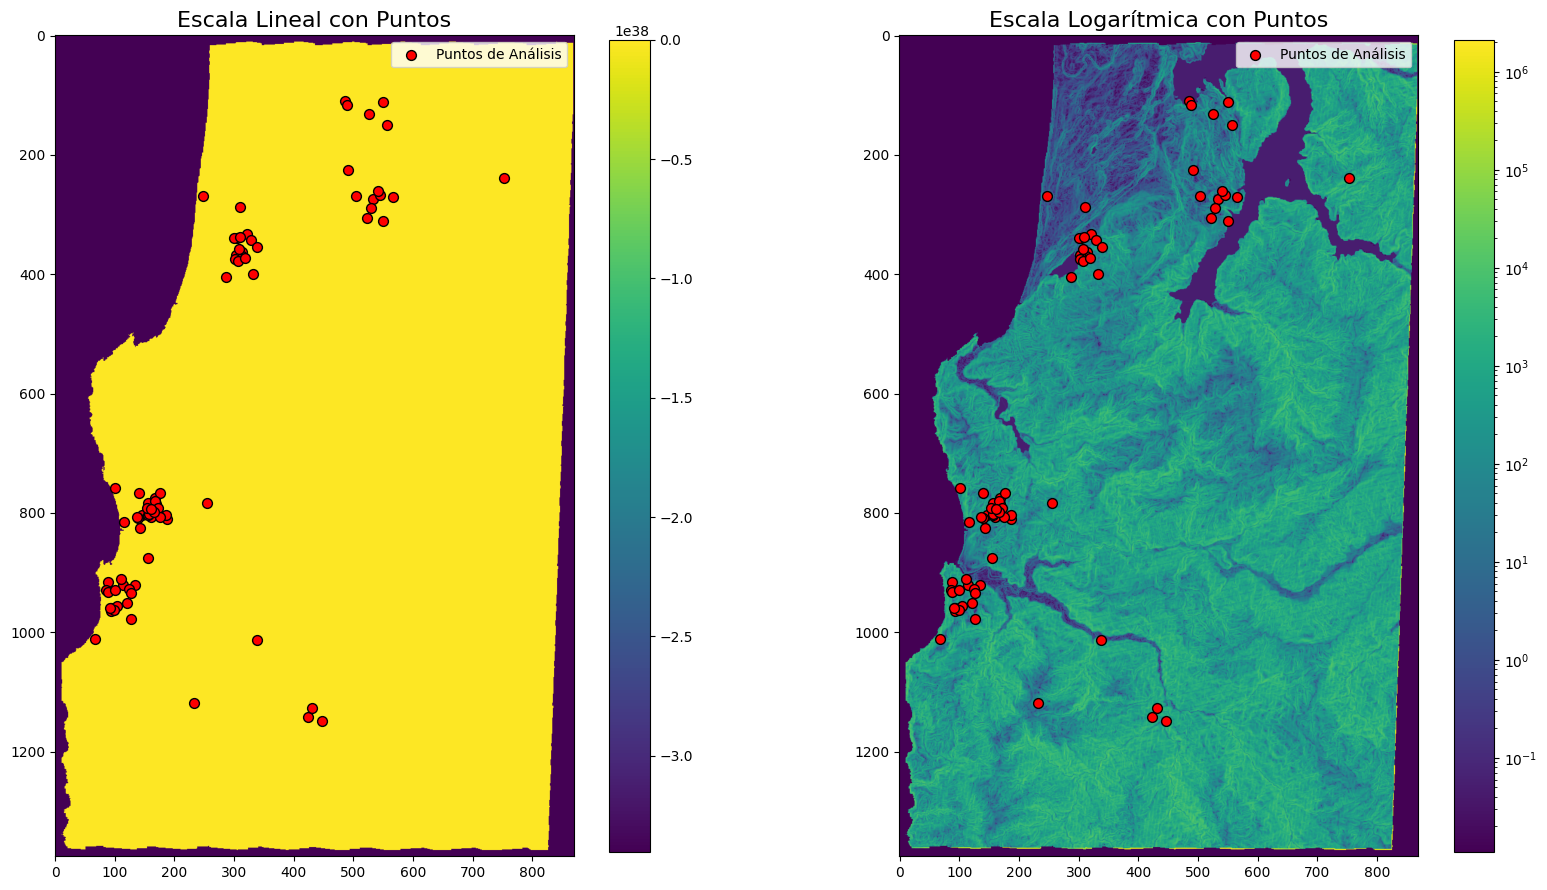

In [5]:
# ==============================================================================
# --- CELDA 4: VISUALIZACIÓN DIAGNÓSTICA ---
# ==============================================================================
print("\nIniciando visualización diagnóstica del ráster de coste y puntos...")
try:
    # Cargar el ráster de coste
    with rasterio.open(COST_RASTER_PATH) as src:
        cost_data = src.read(1)
        transform = src.transform  # Guardar la transformación para convertir coordenadas

        # Preparar datos para la escala logarítmica
        min_pos_val = np.min(cost_data[cost_data > 0]) if np.any(cost_data > 0) else 1e-9
        cost_data_log = np.where(cost_data <= 0, min_pos_val, cost_data)

        # Cargar los puntos
        points_gdf = gpd.read_file(ALL_POINTS_SHAPEFILE)
        
        # Convertir las coordenadas de los puntos a píxeles
        point_pixels_x = []
        point_pixels_y = []
        for point in points_gdf.geometry:
            row, col = rasterio.transform.rowcol(transform, point.x, point.y)
            point_pixels_x.append(col)
            point_pixels_y.append(row)

        # Crear la figura y los ejes
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 9))

        # --- Subplot 1: Escala Lineal ---
        im1 = ax1.imshow(cost_data, cmap='viridis')
        fig.colorbar(im1, ax=ax1, fraction=0.046, pad=0.04)
        ax1.set_title('Escala Lineal con Puntos', fontsize=16)
        ax1.scatter(point_pixels_x, point_pixels_y, c='red', edgecolor='black', s=50, label='Puntos de Análisis', zorder=5)
        ax1.legend()

        # --- Subplot 2: Escala Logarítmica ---
        im2 = ax2.imshow(cost_data_log, cmap='viridis', norm=LogNorm())
        fig.colorbar(im2, ax=ax2, fraction=0.046, pad=0.04)
        ax2.set_title('Escala Logarítmica con Puntos', fontsize=16)
        ax2.scatter(point_pixels_x, point_pixels_y, c='red', edgecolor='black', s=50, label='Puntos de Análisis', zorder=5)
        ax2.legend()

        plt.tight_layout()
        plt.show()

except FileNotFoundError as e:
    print(f"ADVERTENCIA: No se encontró un archivo necesario para la visualización: {e}. Saltando visualización.")
except Exception as e:
    print(f"Ocurrió un error durante la visualización: {e}")
    import traceback; traceback.print_exc()

In [ ]:
# ==============================================================================
# --- CELDA 5: LÓGICA PRINCIPAL DE EJECUCIÓN ---
# ==============================================================================

print("\n--- INICIANDO PROCESO DE ANÁLISIS DE RUTAS ---\n")
os.makedirs(OUTPUT_DIR, exist_ok=True)
memmap_path = os.path.join(OUTPUT_DIR, 'shared_cost_surface.mmap')
try:
    all_points, points_crs = dl.load_points_as_dict(ALL_POINTS_SHAPEFILE, ID_FIELD_NAME)
    
    with dl.load_raster(COST_RASTER_PATH) as src:
        raster_shape, raster_dtype = src.shape, src.dtypes[0]
        cost_data_memmap = np.memmap(memmap_path, dtype=raster_dtype, mode='w+', shape=raster_shape)
        cost_data_memmap[:] = src.read(1)
        cost_data_memmap.flush()
        
        # --- INICIO DE LA MODIFICACIÓN CLAVE ---
        # Una vez que los datos están escritos en el disco, ya no necesitamos
        # el objeto de escritura en el proceso principal. Al eliminarlo,
        # se libera el bloqueo sobre el archivo, previniendo el PermissionError.
        del cost_data_memmap
        # --- FIN DE LA MODIFICACIÓN CLAVE ---
        
        # Usamos la máscara que ya fue creada y validada en la Celda 3.5
        shared_data = {
            'src_transform': src.transform, 'src_crs': src.crs, 'src_nodata': src.nodata, 'src_res': src.res,
            'DOWNSAMPLING_FACTORS': DOWNSAMPLING_FACTORS, 'CORRIDOR_BUFFER_PIXELS': CORRIDOR_BUFFER_PIXELS,
            'HEURISTIC_WEIGHT': HEURISTIC_WEIGHT, 'OUTPUT_DIR': OUTPUT_DIR, 'memmap_path': memmap_path,
            'raster_dtype': raster_dtype, 'raster_shape': raster_shape, 'RESAMPLING_METHOD_NAME': RESAMPLING_METHOD_NAME,
            'main_search_mask': main_search_mask
        }

    sorted_points = sorted(all_points.items())
    tasks = [(o_id, o_coords, d_id, d_coords, shared_data) for i, (o_id, o_coords) in enumerate(sorted_points) for d_id, d_coords in sorted_points[i+1:]]
    
    print(f"Se han preparado {len(tasks)} pares únicos para procesar.")
    warm_up_numba()
    
    # El monitor no es necesario para N_JOBS=1
    start_time = time.time()
    results = Parallel(n_jobs=N_JOBS)(delayed(lcp_worker)(task) for task in tqdm(tasks, desc="Progreso General"))
    total_duration = time.time() - start_time

    exitos = [r for r in results if r[0] == "Éxito"]
    print("\n" + "="*50)
    print("--- RESUMEN DE EJECUCIÓN ---")
    print(f"Proceso completado en {total_duration:.2f} segundos.")
    print(f"Rutas calculadas con éxito: {len(exitos)} de {len(tasks)}")

except Exception as e:
    print(f"\nOcurrió un error fatal en la ejecución: {e}")
    import traceback; traceback.print_exc()
finally:
    if os.path.exists(memmap_path):
        os.remove(memmap_path)
    print("\n--- ANÁLISIS COMPLETADO ---")


--- INICIANDO PROCESO DE ANÁLISIS DE RUTAS ---

Cargando puntos desde: Sitios Vergel area estudio.gpkg
  ADVERTENCIA: Campo 'fid' no encontrado en propiedades. Se usará el 'feature.id' (fid del GeoPackage).
Se cargaron 78 puntos.
Cargando raster desde: Coste_CN_corregido2.tif
Se han preparado 3003 pares únicos para procesar.
Calentando (pre-compilando) funciones de Numba...
Calentamiento de Numba completado.


Progreso General:   1%|▌                                                             | 30/3003 [00:12<24:29,  2.02it/s]

In [ ]:
# ==============================================================================
# --- CELDA 4: VISUALIZACIÓN DE LA RED COMPLETA (TODOS CON TODOS) ---
# ==============================================================================
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
import geopandas as gpd
import pandas as pd
import rasterio
import rasterio.plot
from rasterio.windows import from_bounds
import glob

print("Iniciando la visualización de la red completa de rutas...")

try:
    # --- 1. Encontrar y cargar TODAS las rutas generadas ---
    # MODIFICACIÓN: El patrón glob ahora busca cualquier ruta final, sin especificar origen.
    final_route_files = glob.glob(os.path.join(OUTPUT_DIR, 'ruta_final_*.shp'))

    if not final_route_files:
        print("No se encontraron archivos de rutas finales para visualizar.")
    else:
        # Cargar todas las rutas en un único GeoDataFrame
        final_routes_gdf = pd.concat([gpd.read_file(f) for f in final_route_files], ignore_index=True)
        
        # --- 2. Determinar la extensión total con margen ---
        minx, miny, maxx, maxy = final_routes_gdf.total_bounds
        margin = 100
        buffered_bounds = (minx - margin, miny - margin, maxx + margin, maxy + margin)
        
        # --- 3. Cargar la porción del raster ---
        with rasterio.open(COST_RASTER_PATH) as src:
            window = from_bounds(*buffered_bounds, transform=src.transform)
            raster_data = src.read(1, window=window)
            window_transform = src.window_transform(window)

        # --- 4. Cargar todos los puntos ---
        points_gdf = gpd.read_file(ALL_POINTS_SHAPEFILE)

        # --- 5. Crear el mapa ---
        fig, ax = plt.subplots(figsize=(18, 18))
        rasterio.plot.show(raster_data, transform=window_transform, ax=ax, cmap='viridis', norm=LogNorm(), alpha=0.8)
        
        # MODIFICACIÓN: Dibujar todas las rutas con alta transparencia y líneas finas
        final_routes_gdf.plot(
            ax=ax,
            edgecolor='red',
            linewidth=0.8,  # Líneas más finas
            label='Rutas Calculadas',
            alpha=0.5,      # Alta transparencia para ver superposiciones
            zorder=3
        )
        
        # MODIFICACIÓN: Dibujar todos los puntos con el mismo estilo
        points_gdf.plot(
            ax=ax,
            color='yellow',
            markersize=50,
            ec='black',
            label='Nodos de la Red',
            zorder=5
        )

        # Configuración final del mapa
        ax.set_title('Red Completa de Rutas de Menor Costo', fontsize=20)
        ax.set_xlabel("Coordenada X"); ax.set_ylabel("Coordenada Y")
        ax.legend(); plt.grid(True, linestyle='--', alpha=0.5); plt.tight_layout(); plt.show()

except Exception as e:
    print(f"Ocurrió un error durante la visualización: {e}")
    import traceback
    traceback.print_exc()